<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Diabetes-Prediction-Using-LGBM-and-XGBoost/blob/main/Diabetes-Prediction-Using-LGBM-and-XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploratory Data Analysis (EDA):

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/diabetes (1).csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


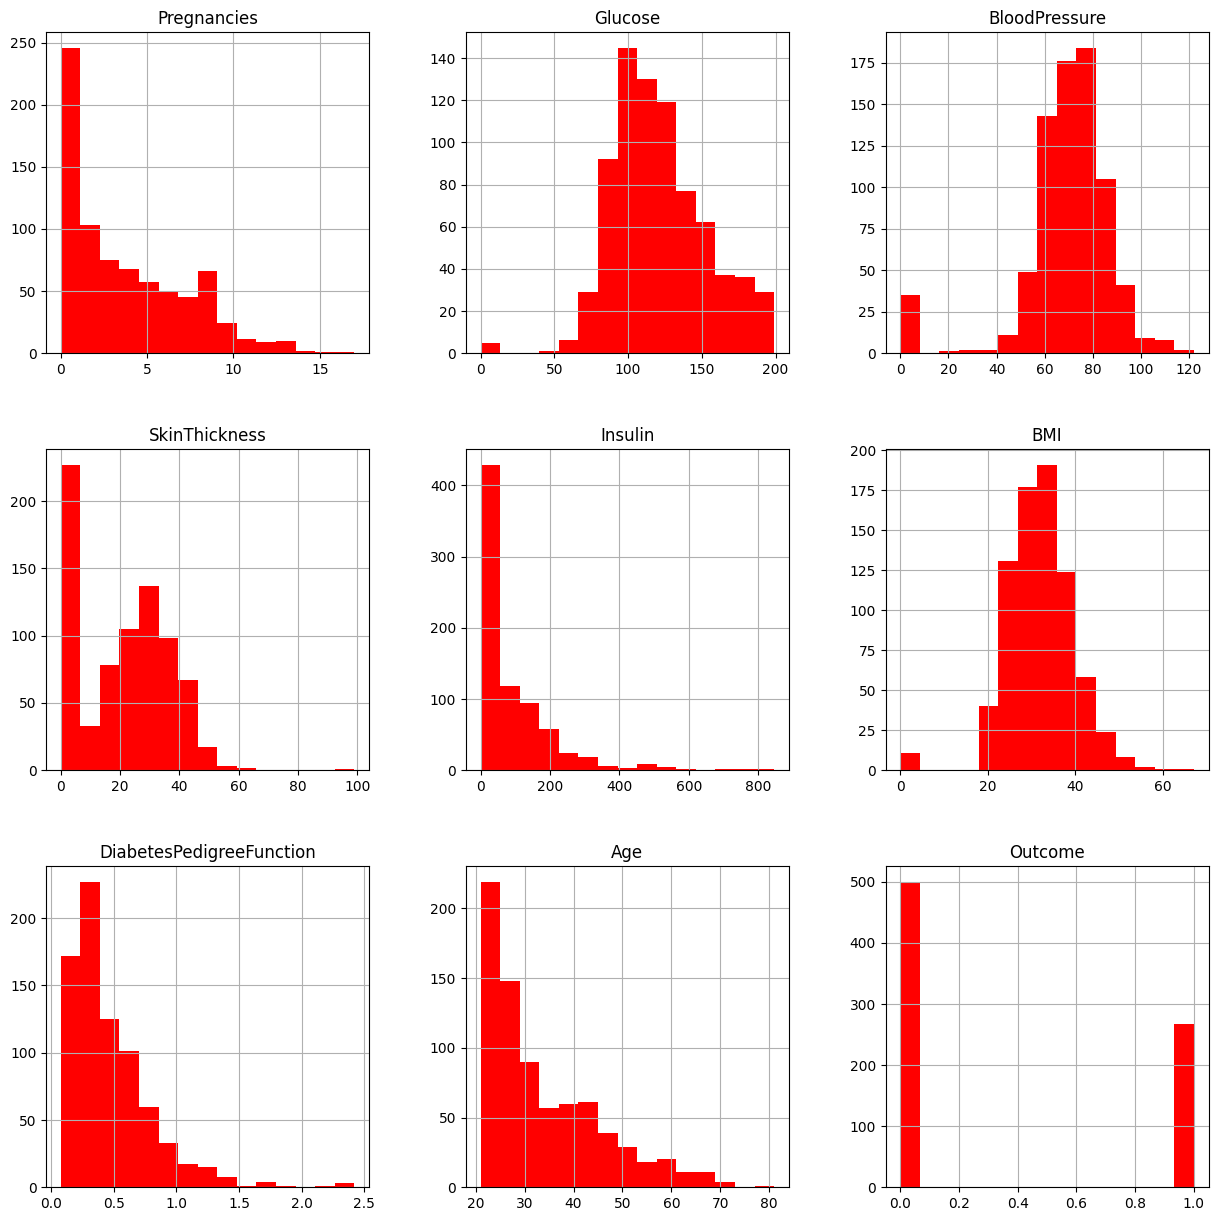

In [ ]:
df.hist(bins=15,figsize=(15,15),color='red')
plt.show()

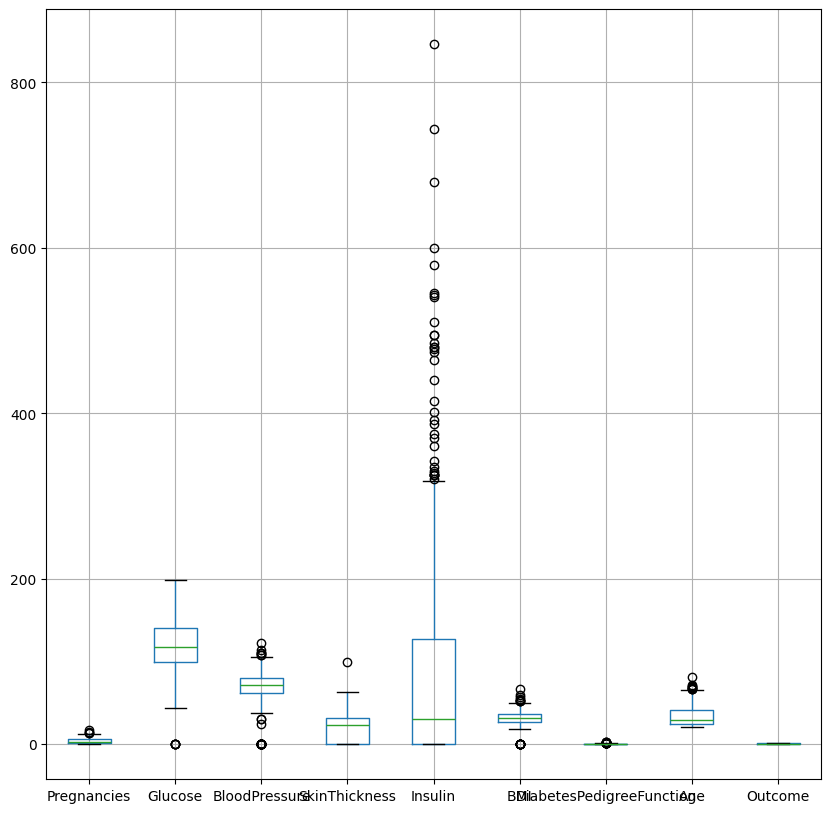

In [ ]:
df.boxplot(figsize=(10,10))
plt.show()

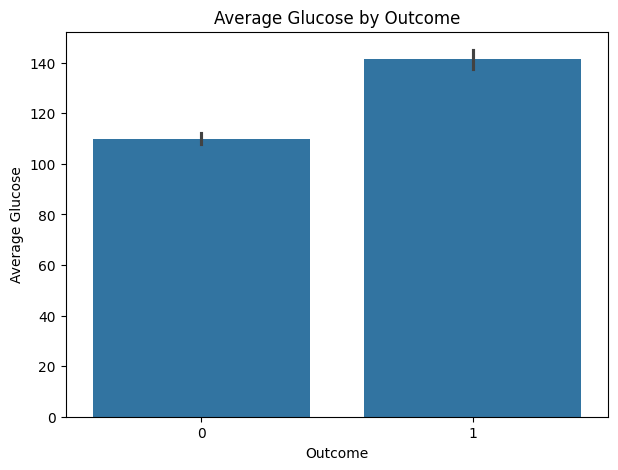

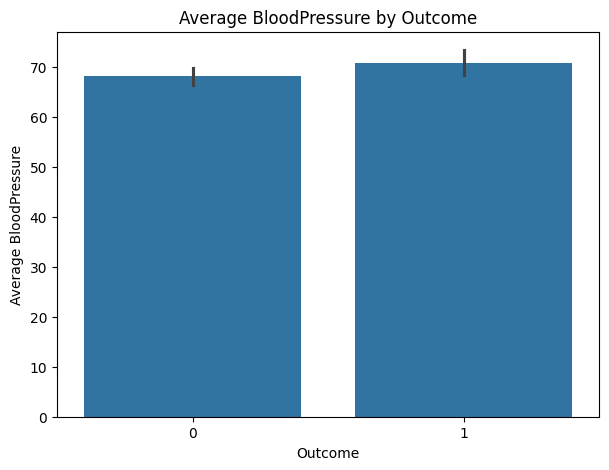

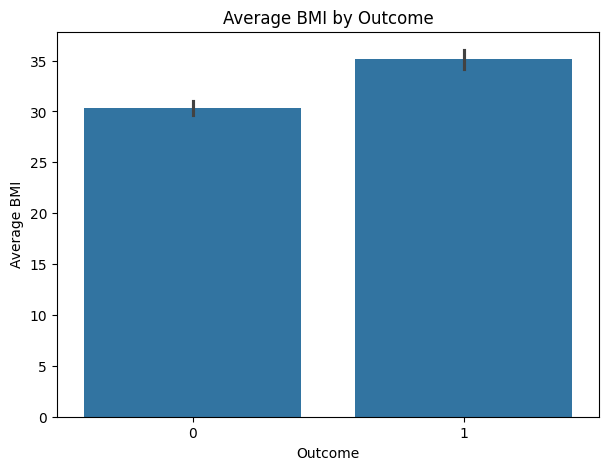

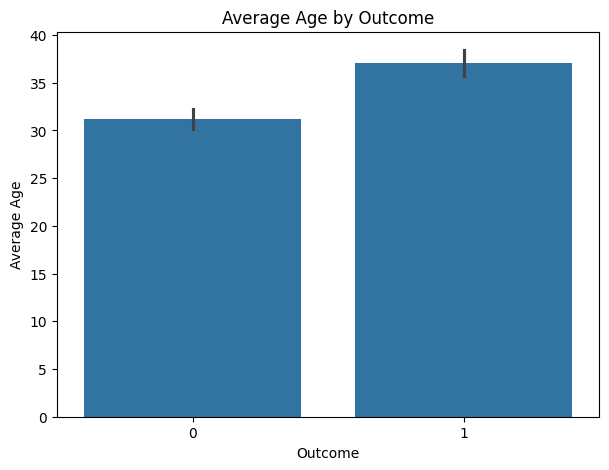

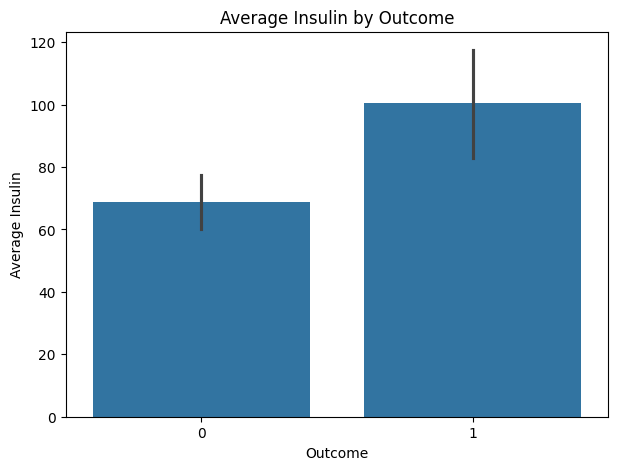

In [ ]:
features = ["Glucose", "BloodPressure", "BMI", "Age", "Insulin"]

for feature in features:
    plt.figure(figsize=(7, 5))

    sns.barplot(
        data=df,
        x="Outcome",
        y=feature
    )

    plt.title(f"Average {feature} by Outcome")
    plt.xlabel("Outcome")
    plt.ylabel(f"Average {feature}")

    plt.show()

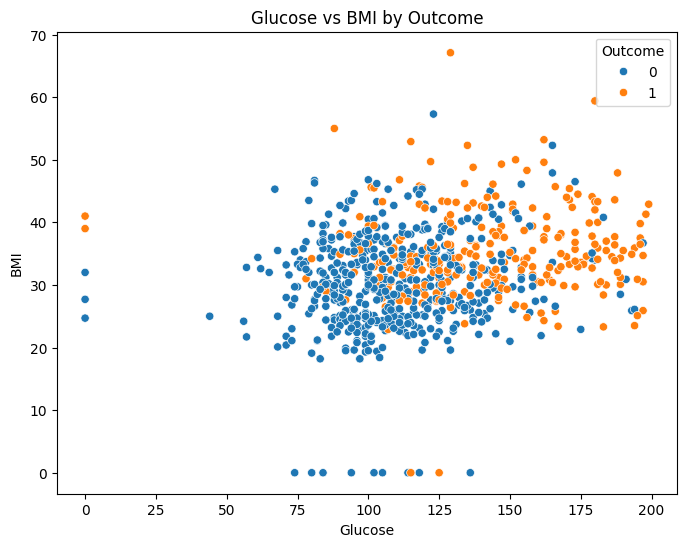

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)
plt.title("Glucose vs BMI by Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

Inferences

*   The dataset contains 768 observations and 9 columns.
*   Outcome = 0 represents non-diabetic cases and Outcome = 1 represents diabetic cases.
*   There are no actual NaN/missing values in the dataset.However, some features contain 0 values that may be unrealistic
*   Insulin has particularly large variation, ranging from 0 to 846, suggesting strong skewness and potential extreme observations.
*   Pregnancies, Age, BMI, and other variables also show considerable variation.
*   Insulin is particularly noticeable because of its very large maximum value compared with its median.
*   The scatter and bar plots show that diabetic and non-diabetic observations overlap.Therefore, no single feature can perfectly separate the two classes.
A combination of features is likely to provide better classification.









# Data Preprocessing:

In [ ]:
#Replace 0 with Nan
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns] = df[columns].replace(0, np.nan)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
#impute using the median
for column in columns:
    df[column] = df[column].fillna(df[column].median())

No categorical variables are present in the dataset, so encoding techniques such as one-hot encoding or label encoding are not required.

In [ ]:
#Scaling using standard scaler
from sklearn.preprocessing import StandardScaler
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Building Predictive Models:

Split the preprocessed dataset

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Evaluation function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

LightGBM

In [ ]:
from lightgbm import LGBMClassifier
#create the model
lgbm = LGBMClassifier(random_state=42)
#Train the model
lgbm.fit(X_train, y_train)
#Predict the values
y_pred_lgbm = lgbm.predict(X_test)
evaluate_model(y_test, y_pred_lgbm)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


XGBoost

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
evaluate_model(y_test, y_pred_xgb)

Accuracy : 0.7727272727272727
Precision: 0.7021276595744681
Recall   : 0.6111111111111112
F1 Score : 0.6534653465346535


LightGBM-Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    lgbm,
    X,
    y,
    cv=5,
    scoring="f1"
)
print("CV F1 Scores:", scores)
print("Mean CV F1:", scores.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LightGBM — GridSearchCV

In [ ]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)
param_grid_lgbm = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "num_leaves": [15, 31, 50]
}
grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_lgbm.fit(X_train, y_train)
print("Best Parameters:", grid_lgbm.best_params_)
print("Best CV F1 Score:", grid_lgbm.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
Best CV F1 Score: 0.6489340201315609


In [ ]:
best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)
evaluate_model(y_test, y_pred_lgbm)

Accuracy : 0.7597402597402597
Precision: 0.673469387755102
Recall   : 0.6111111111111112
F1 Score : 0.6407766990291263


XGBoost-Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("CV F1 Scores:", scores)
print("Mean CV F1:", scores.mean())

CV F1 Scores: [0.61111111 0.62068966 0.60606061 0.67961165 0.65346535]
Mean CV F1: 0.6341876738728442


XGBoost — GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV F1 Score:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best CV F1 Score: 0.6254316271963332


In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
evaluate_model(y_test, y_pred_xgb)

Accuracy : 0.7662337662337663
Precision: 0.6875
Recall   : 0.6111111111111112
F1 Score : 0.6470588235294118


# Comparative Analysis:

```
LightGBM:

Best test F1: 0.6538
Best test recall: 0.6296
Accuracy: 76.62%

XGBoost:

Best test accuracy: 77.27%
Best test precision: 70.21%
Best test F1: 0.6535
CV F1: 0.6342
```


*   LightGBM achieved an accuracy of 76.62% and an F1-score of 0.6538, while XGBoost achieved an accuracy of 77.27% and an F1-score of 0.6535. XGBoost obtained a slightly higher mean cross-validation F1-score of 0.6342 compared with 0.6311 for LightGBM.
*   Therefore, XGBoost can be considered slightly better overall, although the difference between the two models is small.
*   Hyperparameter tuning did not improve the test performance, demonstrating that tuning does not always guarantee better results on unseen data.



Both LightGBM and XGBoost produced very similar results. XGBoost achieved slightly higher accuracy and precision, while LightGBM achieved slightly higher recall and F1-score. Since this is a diabetes prediction problem, recall is particularly important because failing to identify a diabetic patient can be more serious than incorrectly predicting diabetes for a non-diabetic patient. Therefore, LightGBM can be preferred if detecting positive cases is the main priority, while XGBoost can be preferred if overall accuracy and precision are prioritized.

Bar Chart to visualize the performance

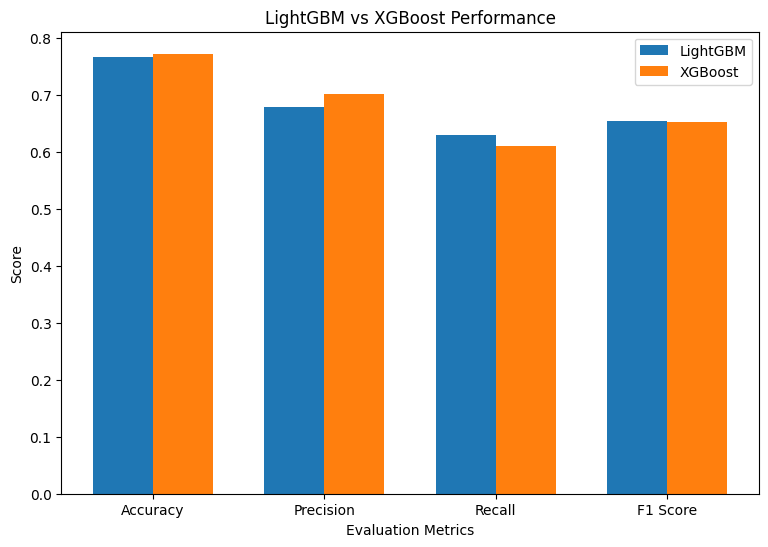

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

lgbm_scores = [0.7662, 0.6800, 0.6296, 0.6538]
xgb_scores = [0.7727, 0.7021, 0.6111, 0.6535]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(x - width/2, lgbm_scores, width, label="LightGBM")
plt.bar(x + width/2, xgb_scores, width, label="XGBoost")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("LightGBM vs XGBoost Performance")
plt.xticks(x, metrics)
plt.legend()

plt.show()

Interpretation
~~~
LightGBM

*   Slightly higher Recall (62.96%).
*   Slightly higher F1-score (65.38%).
*   Its weakness is lower Precision and Accuracy compared with XGBoost.
*   Better at identifying actual diabetic cases among these two models.However, its precision is lower than XGBoost.
```
```
XGBoost strengths

*   Highest Accuracy (77.27%).
*   Highest Precision (70.21%).
*   Slightly better at making correct positive predictions.
*   Its recall is slightly lower, meaning it misses somewhat more positive cases than LightGBM.
~~~
The visualization shows that LightGBM and XGBoost have very similar performance. XGBoost performs better in accuracy and precision, whereas LightGBM performs slightly better in recall and F1-score. For the Diabetes dataset, LightGBM may be preferable when identifying as many diabetic cases as possible is the priority, while XGBoost may be preferable when precision and overall accuracy are more important.